In [3]:
import pandas as pd

print("NLST Masked Intensity Earlier Params:")
nlst_masked_intensity_earlier_params = pd.read_csv("/data/vedant/MIND/benchmarks/nlst/greedy_registration_masked/keypoint_distances_old_params.csv")
print(nlst_masked_intensity_earlier_params.describe())
print("\n\n")

print("NLST Masked Intensity Tuned Params:")
nlst_masked_intensity_tuned_params = pd.read_csv("/data/vedant/MIND/benchmarks/nlst/greedy_registration_masked/keypoint_distances.csv")
print(nlst_masked_intensity_tuned_params.describe())
print("\n\n")

print("NLST Masked Mind Earlier Params:")
nlst_masked_minds_params = pd.read_csv("/data/vedant/MIND/benchmarks/nlst/greedy_registration_mind_masked/keypoint_distances_old_params.csv")
print(nlst_masked_minds_params.describe())
print("\n\n")

# print("NLST Masked Mind Tuned Params:")
# nlst_masked_minds_tuned_params = pd.read_csv("/data/vedant/MIND/benchmarks/nlst/greedy_registration_mind_masked/keypoint_distances.csv")
# print(nlst_masked_minds_tuned_params.describe())
print("\n\n")

NLST Masked Intensity Earlier Params:
       dist_initial_physical  dist_final_physical
count             210.000000           210.000000
mean                9.079160             1.295194
std                 3.217559             1.046764
min                 3.416131             0.711189
25%                 6.901791             0.899035
50%                 8.569040             1.030945
75%                10.597270             1.229641
max                21.484379             9.694344



NLST Masked Intensity Tuned Params:
       dist_initial_physical  dist_final_physical
count             177.000000           177.000000
mean                8.846203             1.186286
std                 3.251723             0.766232
min                 3.416131             0.668898
25%                 6.454205             0.853342
50%                 8.406698             0.987644
75%                10.391784             1.182050
max                21.484379             8.268760



NLST Masked Mind Ear

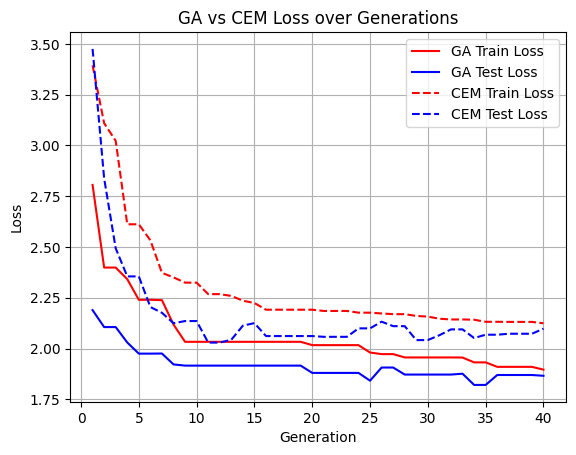

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

ga = pd.read_csv('/data/vedant/MIND/outputs/evotorch/masked_res_gn_gelu_resgn_32h_8out/metrics.csv')
cem = pd.read_csv('/data/vedant/MIND/outputs/evotorch/masked_res_gn_gelu_cem_resgn/metrics.csv')  
plt.plot(ga['generation'], ga['best_train_mean'], label='GA Train Loss', color='red')
plt.plot(ga['generation'], ga['test_mean'], label='GA Test Loss', color='blue')

plt.plot(cem['generation'], cem['best_train_mean'], label='CEM Train Loss', linestyle='--', color='red')
plt.plot(cem['generation'], cem['test_mean'], label='CEM Test Loss', linestyle='--', color='blue')

plt.xlabel('Generation')
plt.ylabel('Loss')
plt.title('GA vs CEM Loss over Generations')
plt.legend()
plt.grid()
plt.show()


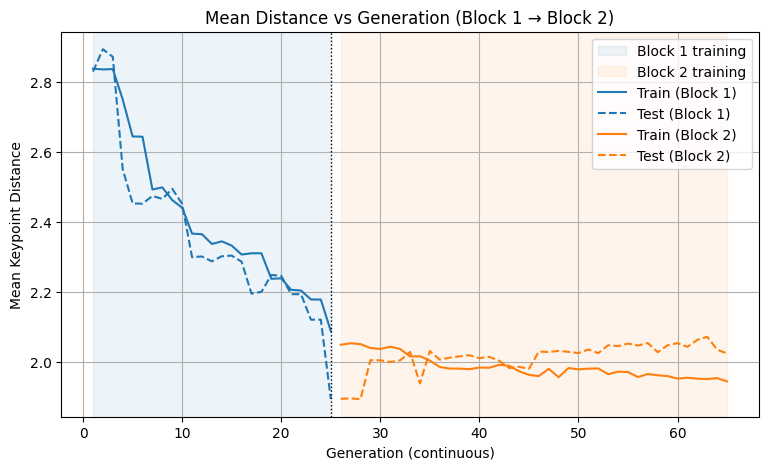

In [ ]:

evotorch1 = pd.read_csv("/data/vedant/MIND/outputs/evotorch/masked_res_gn_gelu/metrics.csv")
evotorch2 = pd.read_csv("/data/vedant/MIND/outputs/evotorch/masked_res_gn_gelu_resgn_cascade2/metrics.csv")

cut = 25
ev1 = evotorch1[evotorch1["generation"] <= cut]

g1 = ev1["generation"]
g2 = evotorch2["generation"] + cut

plt.figure(figsize=(9,5))

# Shaded regions
plt.axvspan(g1.min(), g1.max(), color="C0", alpha=0.08, label="Block 1 training")
plt.axvspan(g2.min(), g2.max(), color="C1", alpha=0.08, label="Block 2 training")

# Curves
plt.plot(g1, ev1["best_train_mean"], color="C0", label="Train (Block 1)")
plt.plot(g1, ev1["test_mean"], color="C0", linestyle="--", label="Test (Block 1)")
plt.plot(g2, evotorch2["best_train_mean"], color="C1", label="Train (Block 2)")
plt.plot(g2, evotorch2["test_mean"], color="C1", linestyle="--", label="Test (Block 2)")

plt.axvline(cut, color="k", linestyle=":", linewidth=1)

plt.xlabel("Generation (continuous)")
plt.ylabel("Mean Keypoint Distance")
plt.title("Mean Distance vs Generation (Block 1 → Block 2)")
plt.grid(True)
plt.legend()
plt.show()


In [10]:
import sys
from pathlib import Path
import torch
import pandas as pd

sys.path.insert(0, "/data/vedant/MIND/src")
sys.path.insert(0, "/data/vedant/FireANTs-latest")

from fireants.io.image import Image, BatchedImages
from fireants.io.keypoints import Keypoints, BatchedKeypoints, compute_keypoint_distance
from fireants.registration.greedy import GreedyRegistration
from mind.evotorch.data import build_pairs
from mind.utils.io import load_keypoints_csv

device = "cuda" if torch.cuda.is_available() else "cpu"
root = Path("/data/vedant/MIND")

pairs = build_pairs(root)
sample = pairs[0]

print("Using pair:", sample.case_id)
print("fixed:", sample.fixed_path)
print("moving:", sample.moving_path)

fixed_img = Image.load_file(str(sample.fixed_path), device=device)
moving_img = Image.load_file(str(sample.moving_path), device=device)
fixed_mask = Image.load_file(str(sample.fixed_mask), device=device)
moving_mask = Image.load_file(str(sample.moving_mask), device=device)

# masked_* expects mask as last channel
fixed_img_m = fixed_img.concat(fixed_mask)
moving_img_m = moving_img.concat(moving_mask)

fixed_batch = BatchedImages([fixed_img_m])
moving_batch = BatchedImages([moving_img_m])

fixed_pts = load_keypoints_csv(sample.fixed_kp)
moving_pts = load_keypoints_csv(sample.moving_kp)
fixed_kp = Keypoints(fixed_pts, fixed_img, device=device, space="pixel")
moving_kp = Keypoints(moving_pts, moving_img, device=device, space="pixel")
fixed_kp_batch = BatchedKeypoints([fixed_kp])
moving_kp_batch = BatchedKeypoints([moving_kp])

def run_loss(loss_type: str):
    if device == "cuda":
        torch.cuda.empty_cache()

    reg_kwargs = dict(
        fixed_images=fixed_batch,
        moving_images=moving_batch,
        loss_type=loss_type,
        cc_kernel_size=15,
        scales=[4, 2, 1],
        iterations=[200, 100, 50],
        smooth_warp_sigma = 0.5499451812055443,
        smooth_grad_sigma = 3.6329020170516038,
        progress_bar=True,
    )

    # only for fused loss, pass via loss_params
    if "fusedcc" in loss_type:
        loss_params={
            "smooth_nr": 1e-5/(15**3),   # so effective is 1e-5
            "smooth_dr": 1e-5/(15**3),
            "use_ants_gradient": False,  # key
            "use_separable": False,      # stricter/more faithful
        }
        reg_kwargs["loss_params"] = loss_params

    reg = GreedyRegistration(**reg_kwargs)


    with torch.no_grad():
        before = reg.loss_fn(moving_batch(), fixed_batch()).item()

    init_tre = compute_keypoint_distance(
        fixed_kp_batch, moving_kp_batch, space="physical", reduction="mean"
    ).item()

    reg.optimize()

    with torch.no_grad():
        moved = reg.evaluate(fixed_batch, moving_batch)
        after = reg.loss_fn(moved, fixed_batch()).item()

    moved_kp_batch = reg.evaluate_keypoints(fixed_kp_batch, moving_kp_batch)
    final_tre = compute_keypoint_distance(
        moved_kp_batch, moving_kp_batch, space="physical", reduction="mean"
    ).item()

    return reg, moved, before, after, init_tre, final_tre

reg_cc, moved_cc, cc_before, cc_after, cc_init_tre, cc_final_tre = run_loss("masked_cc")
reg_fcc, moved_fcc, fcc_before, fcc_after, fcc_init_tre, fcc_final_tre = run_loss("masked_fusedcc")

with torch.no_grad():
    cc_on_ccmoved = reg_cc.loss_fn(moved_cc, fixed_batch()).item()
    fcc_on_ccmoved = reg_fcc.loss_fn(moved_cc, fixed_batch()).item()
    cc_on_fccmoved = reg_cc.loss_fn(moved_fcc, fixed_batch()).item()
    fcc_on_fccmoved = reg_fcc.loss_fn(moved_fcc, fixed_batch()).item()

df = pd.DataFrame(
    [
        ["masked_cc", cc_before, cc_after, cc_init_tre, cc_final_tre],
        ["masked_fusedcc", fcc_before, fcc_after, fcc_init_tre, fcc_final_tre],
    ],
    columns=["loss_type", "before_opt", "after_opt", "init_tre_mm", "final_tre_mm"],
)
print("\nPre/Post optimize loss + TRE:")
display(df)

cross = pd.DataFrame(
    [
        ["moved_from_masked_cc", cc_on_ccmoved, fcc_on_ccmoved, abs(cc_on_ccmoved - fcc_on_ccmoved)],
        ["moved_from_masked_fusedcc", cc_on_fccmoved, fcc_on_fccmoved, abs(cc_on_fccmoved - fcc_on_fccmoved)],
    ],
    columns=["moved_tensor", "cc_value", "fusedcc_value", "abs_diff"],
)
print("\nCross-check on same moved tensor:")
display(cross)


Using pair: LungCT_0001
fixed: /data/vedant/MIND/data/LungCT_L2R_preprocessed/imagesTr/LungCT_0001_0000.nii.gz
moving: /data/vedant/MIND/data/LungCT_L2R_preprocessed/imagesTr/LungCT_0001_0001.nii.gz


INFO:fireants.registration.abstract:Masked mode specified, will use cc function with masking if it supports it.
INFO:fireants.registration.abstract:Setting iterations for loss function
INFO:fireants.registration.abstract:Setting scales for loss function
INFO:fireants.registration.abstract:Registration of type GreedyRegistration initialized with dtype torch.float32
INFO:fireants.losses.cc:setting current scale and iterations to 4 and 200
scale: 4, iter: 199/200, loss: -0.980415: 100%|██████████| 200/200 [00:03<00:00, 62.74it/s] 
INFO:fireants.losses.cc:setting current scale and iterations to 2 and 100
scale: 2, iter: 78/100, loss: -0.962363:  78%|███████▊  | 78/100 [00:00<00:00, 89.81it/s] 
INFO:fireants.losses.cc:setting current scale and iterations to 1 and 50
scale: 1, iter: 49/50, loss: -0.833517: 100%|██████████| 50/50 [00:08<00:00,  5.80it/s]
INFO:fireants.registration.abstract:Masked mode specified, will use fusedcc function with masking if it supports it.
INFO:fireants.registrat


Pre/Post optimize loss + TRE:


,loss_type,before_opt,after_opt,init_tre_mm,final_tre_mm
0,masked_cc,-0.338590,-0.833892,20.242239,4.741179
1,masked_fusedcc,-0.029885,-0.026979,20.242239,21.492996



Cross-check on same moved tensor:


,moved_tensor,cc_value,fusedcc_value,abs_diff
0,moved_from_masked_cc,-0.833892,-0.711025,0.122867
1,moved_from_masked_fusedcc,-0.419069,-0.026979,0.392089


In [9]:
print("cc loss fn:", type(reg_cc.loss_fn).__name__)
print("fcc loss fn:", type(reg_fcc.loss_fn).__name__)
print("fcc use_ants_gradient:", reg_fcc.loss_fn.use_ants_gradient)
print("fcc use_separable:", reg_fcc.loss_fn.use_separable)
print("cc smooth:", reg_cc.loss_fn.smooth_nr, reg_cc.loss_fn.smooth_dr)
print("fcc smooth:", reg_fcc.loss_fn.smooth_nr, reg_fcc.loss_fn.smooth_dr)
print("cc masked:", reg_cc.loss_fn.masked, "mode:", reg_cc.loss_fn.mask_mode)
print("fcc masked:", reg_fcc.loss_fn.masked, "mode:", reg_fcc.loss_fn.mask_mode)


cc loss fn: LocalNormalizedCrossCorrelationLoss
fcc loss fn: FusedLocalNormalizedCrossCorrelationLoss
fcc use_ants_gradient: False
fcc use_separable: False
cc smooth: 1e-05 1e-05
fcc smooth: 1e-05 1e-05
cc masked: True mode: mult
fcc masked: True mode: mult


In [1]:
import pandas as pd
nlst = pd.read_csv("/data/vedant/MIND/benchmarks/nlst/greedy_registration_mind_masked/keypoint_distances.csv")
display(nlst.describe())

,dist_initial_physical,dist_final_physical
count,210.000000,210.000000
mean,9.079160,1.229402
std,3.217559,1.076169
min,3.416131,0.675819
25%,6.901791,0.888762
50%,8.569040,1.000167
75%,10.597270,1.228952
max,21.484379,11.246688


In [15]:
# 0-15 train,
# 16-19 test, calculate te average

from torch import mm


train_mean = convexadam.iloc[:16]['dist_final_physical'].mean()
test_mean = convexadam.iloc[16:]['dist_final_physical'].mean()
print(f"ConvexAdam Train Mean Keypoint Distance (1-16): {train_mean:.4f} mm")
print(f"ConvexAdam Test Mean Keypoint Distance (17-20): {test_mean:.4f} mm")
all_mean = convexadam['dist_final_physical'].mean()
print(f"Mean Keypoint Distance (all samples): {all_mean:.4f} mm")

ConvexAdam Train Mean Keypoint Distance (1-16): 2.6178 mm
ConvexAdam Test Mean Keypoint Distance (17-20): 3.5530 mm
Mean Keypoint Distance (all samples): 2.8048 mm


In [10]:
convexadam

,case,fixed_image,moving_image,dist_initial_physical,dist_final_physical
0,LungCT_0001,LungCT_0001_0000.nii.gz,LungCT_0001_0001.nii.gz,20.242239,2.602782
1,LungCT_0002,LungCT_0002_0000.nii.gz,LungCT_0002_0001.nii.gz,16.514454,5.248492
2,LungCT_0003,LungCT_0003_0000.nii.gz,LungCT_0003_0001.nii.gz,9.599362,1.669601
3,LungCT_0004,LungCT_0004_0000.nii.gz,LungCT_0004_0001.nii.gz,5.957952,1.428109
4,LungCT_0005,LungCT_0005_0000.nii.gz,LungCT_0005_0001.nii.gz,14.443996,3.895994
5,LungCT_0006,LungCT_0006_0000.nii.gz,LungCT_0006_0001.nii.gz,13.861918,3.634719
6,LungCT_0007,LungCT_0007_0000.nii.gz,LungCT_0007_0001.nii.gz,8.077776,1.128769
7,LungCT_0008,LungCT_0008_0000.nii.gz,LungCT_0008_0001.nii.gz,14.063132,2.077228
8,LungCT_0009,LungCT_0009_0000.nii.gz,LungCT_0009_0001.nii.gz,16.687590,5.240635
9,LungCT_0010,LungCT_0010_0000.nii.gz,LungCT_0010_0001.nii.gz,7.747270,3.633242
